# Replication of Figure 4A–G

**Manuscript:** Mantas et al. (2026) — *Anxa1+ dopamine neuron vulnerability defines prodromal Parkinson's disease bradykinesia and procedural motor learning impairment*

**Figure reference:** Figure 4 — *Anxa1+ dopamine neurons do not encode motivational value.*

> Figure 4A–G: fiber photometry recordings from caudoputamen (CP) aligned to water drop
> contact during the forelimb reaching-for-water task.

**Panels replicated here:**
- **Panel D** — Z-scored FP signals aligned to water drop contact, Anxa1-GCaMP-dCP vs DAT-GCaMP-dCP
- **Panel E** — Z-scored FP signals aligned to water drop contact, dLight-dCP vs dLight-cCP
- **Panels F–G** — AUC changes in time windows 2 and 3 relative to window 1 (baseline) per group

**Panels not replicated (schematics/microscopy):**
- A: Mouse groups schematic + fluorescence images of injection sites
- B: Schematic of FP recording locations within CP per group
- C: Schematic of the FP setup during water reward delivery

## Experimental design

Water-restricted mice performed a forelimb reaching-for-water task while fiber photometry recorded
striatal activity. Water drop contact events correspond to the ``correct`` reach attempts in the
manual behavior annotations. Four cohorts were compared by crossing indicator identity
(Anxa1-GCaMP, DAT-GCaMP, dLight1.3b) with recording site (dorsal CP = dCP, central/ventral CP = cCP):
- **Anxa1-GCaMP-dCP** (n = 7 mice): activity of Anxa1+ DAN axons in dCP
- **DAT-GCaMP-dCP** (n = 4 mice): activity of all DAN axons in dCP
- **dLight-dCP** (n = 7 mice): dopamine release in dCP
- **dLight-cCP** (n = 6 mice): dopamine release in cCP

**Expected result:** Water contact elicits robust responses in DAT-GCaMP-dCP and dLight-cCP but
not in Anxa1-GCaMP-dCP or dLight-dCP, suggesting that Anxa1+ DAN axons terminating in dCP do not
encode motivational value of natural rewards.

## Setup

In [3]:
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pynwb import read_nwb

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 9

NWB_DIR = Path("../../../nwb_output/water_consumption")

# Peri-event analysis windows (s, relative to water drop contact)
PRE_S = 2.0    # seconds before contact shown in traces
POST_S = 2.0   # seconds after contact shown in traces
# Three analysis windows (W1 = baseline, W2 = peri-contact, W3 = post-contact)
WINDOWS = {
    "W1 (baseline)": (-2.0, -1.0),
    "W2 (peri-contact)": (-1.0, 0.0),
    "W3 (post-contact)": (0.0, 1.0),
}

# Cohort colors matching Figure 4 in the manuscript
COHORT_COLORS = {
    "Anxa1-GCaMP-dCP": "#E08840",   # warm orange
    "DAT-GCaMP-dCP":   "#3CB5A5",   # teal
    "dLight-dCP":      "#9070BC",   # purple
    "dLight-cCP":      "#45B5A8",   # teal
    "other":           "#888888",
}

nwb_files = sorted(NWB_DIR.glob("sub-*/sub-*.nwb"))
print(f"NWB files found: {len(nwb_files)}")
for p in nwb_files:
    print(f"  {p.relative_to(NWB_DIR)}")

NWB files found: 59
  sub-661507/sub-661507_ses-reaching-test-2023-06-20T12-22-30_behavior+image.nwb
  sub-661507/sub-661507_ses-reaching-test-2023-06-21T15-50-26_behavior+image.nwb
  sub-687662/sub-687662_ses-reaching-test-2023-06-20T12-59-52_behavior+image.nwb
  sub-741417/sub-741417_ses-reaching-test-2024-01-17T12-29-35_behavior+image.nwb
  sub-741417/sub-741417_ses-reaching-test-2024-01-18T12-46-22_behavior+image.nwb
  sub-741417/sub-741417_ses-reaching-test-2024-01-23T12-19-41_behavior+image.nwb
  sub-741417/sub-741417_ses-reaching-test-2024-01-31T10-46-20_behavior+image.nwb
  sub-750528/sub-750528_ses-reaching-test-2024-01-17T13-44-25_behavior+image.nwb
  sub-750528/sub-750528_ses-reaching-test-2024-01-18T13-14-49_behavior+image.nwb
  sub-750528/sub-750528_ses-reaching-test-2024-01-23T12-43-44_behavior+image.nwb
  sub-758502/sub-758502_ses-reaching-test-2024-04-23T11-35-02_behavior+image.nwb
  sub-758502/sub-758502_ses-reaching-test-2024-04-24T11-02-18_behavior+image.nwb
  sub-77

## Load all sessions

For each NWB file we pull directly from the file (no hard-coded mouse lists):
- **Indicator** (GCaMP vs dLight) — from `lab_meta_data['fiber_photometry']` → `indicator.label`
- **Recording site** (dCP vs cCP vs SN) — from the fiber photometry table `location` (Allen CCF)
- **Mouse line** (Anxa1-flp vs DAT-Cre) — from `Subject.genotype`
- **Fiber photometry** — isosbestic-corrected dF/F from `processing/ophys/FiberPhotometrySeriesDfOverF`
- **Water-contact events** — `event_times` of the `"correct"` row in `processing/behavior/reaching_events`

The cohort label is assembled from (indicator, genotype, site) so the code handles any combination
that appears in the files.

In [4]:
def _site_from_location(location: str) -> str:
    """Map Allen CCF location string to a short site label used in the manuscript."""
    loc = (location or "").lower()
    if "central caudoputamen" in loc:
        return "cCP"
    if "caudoputamen" in loc:
        return "dCP"
    if "accumbens" in loc:
        return "cCP"
    if "substantia nigra" in loc:
        return "SN"
    return location


def _indicator_short(indicator_label: str) -> str:
    """Reduce indicator label to GCaMP / dLight tag."""
    lab = (indicator_label or "").lower()
    if "dlight" in lab:
        return "dLight"
    if "gcamp" in lab:
        return "GCaMP"
    return indicator_label


def _line_short(genotype: str) -> str:
    """Reduce genotype to Anxa1 / DAT line tag."""
    g = (genotype or "").lower()
    if "anxa1" in g:
        return "Anxa1"
    if "dat" in g:
        return "DAT"
    return genotype


def cohort_label(indicator: str, line: str, site: str) -> str:
    """Compose the cohort tag used in the manuscript (e.g. 'Anxa1-GCaMP-dCP').

    dLight cohorts are pooled across mouse line (the manuscript groups them by site only).
    """
    if indicator == "dLight":
        return f"dLight-{site}"
    return f"{line}-{indicator}-{site}"


def load_session(nwb_path):
    nwb = read_nwb(nwb_path)

    subject_id = nwb.subject.subject_id
    line = _line_short(nwb.subject.genotype)

    fp_table = nwb.lab_meta_data["fiber_photometry"].fiber_photometry_table
    location = fp_table["location"][0]
    site = _site_from_location(location)
    indicator_label = fp_table["indicator"][0].label
    indicator = _indicator_short(indicator_label)

    fp = nwb.processing["ophys"]["FiberPhotometrySeriesDfOverF"]
    signal = fp.data[:].copy()
    timestamps = fp.timestamps[:].copy()

    # reaching_events is an AnnotatedEventsTable in processing/behavior:
    # one row per event type, with a ragged event_times column.
    reach_table = nwb.processing["behavior"]["reaching_events"]
    reach_df = reach_table.to_dataframe()
    correct_row = reach_df[reach_df["label"] == "correct"]
    if len(correct_row) > 0:
        contact_times = np.array(correct_row.iloc[0]["event_times"], dtype=float)
    else:
        contact_times = np.array([], dtype=float)

    nwb.read_io.close()

    return dict(
        path=nwb_path,
        subject_id=subject_id,
        session_id=nwb.session_id,
        line=line,
        indicator=indicator,
        location=location,
        site=site,
        cohort=cohort_label(indicator, line, site),
        signal=signal,
        timestamps=timestamps,
        contact_times=contact_times,
    )


sessions = [load_session(p) for p in nwb_files]

summary = pd.DataFrame([
    dict(
        subject=s["subject_id"],
        session=s["session_id"],
        line=s["line"],
        indicator=s["indicator"],
        location=s["location"],
        site=s["site"],
        cohort=s["cohort"],
        n_contacts=len(s["contact_times"]),
        fp_duration_s=float(s["timestamps"][-1] - s["timestamps"][0]),
    )
    for s in sessions
])
summary

,subject,session,line,indicator,location,site,cohort,n_contacts,fp_duration_s
0,661507,reaching-test-2023-06-20T12-22-30,DAT,GCaMP,Dorsal caudoputamen,dCP,DAT-GCaMP-dCP,16,1812.816670
1,661507,reaching-test-2023-06-21T15-50-26,DAT,GCaMP,Dorsal caudoputamen,dCP,DAT-GCaMP-dCP,4,1824.150003
2,687662,reaching-test-2023-06-20T12-59-52,DAT,GCaMP,Dorsal caudoputamen,dCP,DAT-GCaMP-dCP,31,1818.183329
3,741417,reaching-test-2024-01-17T12-29-35,Anxa1,GCaMP,Dorsal caudoputamen,dCP,Anxa1-GCaMP-dCP,3,1041.916670
4,741417,reaching-test-2024-01-18T12-46-22,Anxa1,GCaMP,Dorsal caudoputamen,dCP,Anxa1-GCaMP-dCP,6,929.633334
5,741417,reaching-test-2024-01-23T12-19-41,Anxa1,GCaMP,Dorsal caudoputamen,dCP,Anxa1-GCaMP-dCP,2,958.850000
6,741417,reaching-test-2024-01-31T10-46-20,Anxa1,GCaMP,Dorsal caudoputamen,dCP,Anxa1-GCaMP-dCP,16,1299.616670
7,750528,reaching-test-2024-01-17T13-44-25,Anxa1,GCaMP,Dorsal caudoputamen,dCP,Anxa1-GCaMP-dCP,16,920.700000
8,750528,reaching-test-2024-01-18T13-14-49,Anxa1,GCaMP,Dorsal caudoputamen,dCP,Anxa1-GCaMP-dCP,17,826.516667
9,750528,reaching-test-2024-01-23T12-43-44,Anxa1,GCaMP,Dorsal caudoputamen,dCP,Anxa1-GCaMP-dCP,16,957.150000


## Peri-event alignment and z-scoring

For each water-contact event we extract the dF/F signal in the window ``[-PRE_S, +POST_S]``
around the contact, z-score using the pre-contact baseline (mean and std of ``[-PRE_S, 0]``),
and average across events within a session. Sessions with no contact events are skipped.

AUC in each of the three analysis windows is computed with the trapezoidal rule on the
z-scored mean trace, matching the "mean AUC across time windows" quantification in Fig. 4D–G.

In [5]:
def compute_peri_event(sess, pre_s=PRE_S, post_s=POST_S, min_coverage=0.8):
    """Z-scored peri-event mean trace around water drop contact events.

    Each event is baselined (mean and std of [-pre_s, 0]) before averaging. Events whose
    window falls outside the FP recording are dropped.
    """
    signal = sess["signal"]
    t = sess["timestamps"]
    events = sess["contact_times"]

    if len(events) == 0:
        return None

    dt = float(np.median(np.diff(t)))
    fs = 1.0 / dt
    n_pre = int(pre_s * fs)
    n_post = int(post_s * fs)
    n_total = n_pre + n_post
    t_axis = np.linspace(-pre_s, post_s, n_total)

    epochs = []
    for onset in events:
        t0 = onset - pre_s
        t1 = onset + post_s
        idx = np.where((t >= t0) & (t < t1))[0]
        if len(idx) < n_total * min_coverage:
            continue
        grid = np.linspace(t0, t1, n_total)
        ep = np.interp(grid, t[idx], signal[idx])
        baseline = ep[:n_pre]
        mu, sd = float(baseline.mean()), float(baseline.std())
        if sd <= 0:
            continue
        epochs.append((ep - mu) / sd)

    if not epochs:
        return None

    arr = np.asarray(epochs)
    return dict(
        t_axis=t_axis,
        mean=arr.mean(axis=0),
        sem=arr.std(axis=0) / np.sqrt(len(arr)),
        n_epochs=len(arr),
    )


def window_auc(t_axis, trace, window):
    lo, hi = window
    mask = (t_axis >= lo) & (t_axis <= hi)
    if mask.sum() < 2:
        return np.nan
    return float(np.trapezoid(trace[mask], t_axis[mask]))


for sess in sessions:
    peri = compute_peri_event(sess)
    sess["peri"] = peri
    if peri is None:
        sess["aucs"] = {name: np.nan for name in WINDOWS}
        continue
    sess["aucs"] = {
        name: window_auc(peri["t_axis"], peri["mean"], win)
        for name, win in WINDOWS.items()
    }

# Per-session table for transparency
rows = []
for s in sessions:
    n_epochs = s["peri"]["n_epochs"] if s["peri"] else 0
    row = dict(subject=s["subject_id"], cohort=s["cohort"], n_epochs=n_epochs)
    row.update(s["aucs"])
    rows.append(row)
per_session_df = pd.DataFrame(rows)
per_session_df

,subject,cohort,n_epochs,W1 (baseline),W2 (peri-contact),W3 (post-contact)
0,661507,DAT-GCaMP-dCP,16,-0.005934,0.004372,0.008387
1,661507,DAT-GCaMP-dCP,4,0.410022,-0.405419,-0.114202
2,687662,DAT-GCaMP-dCP,31,0.071440,-0.069494,-0.133246
3,741417,Anxa1-GCaMP-dCP,3,-0.228367,0.223285,0.106051
4,741417,Anxa1-GCaMP-dCP,6,0.009546,0.012769,-0.098316
5,741417,Anxa1-GCaMP-dCP,2,-0.138110,0.142892,0.028616
6,741417,Anxa1-GCaMP-dCP,16,0.036832,-0.043875,-0.148754
7,750528,Anxa1-GCaMP-dCP,16,-0.150065,0.143815,-0.060328
8,750528,Anxa1-GCaMP-dCP,17,-0.073791,0.068204,-0.064533
9,750528,Anxa1-GCaMP-dCP,16,-0.026274,0.023581,-0.206928


## Panel D — Anxa1-GCaMP-dCP vs DAT-GCaMP-dCP

Z-scored dF/F aligned to water drop contact. Sessions are averaged within each mouse first, then
the grand mean ± SEM is shown across mice. Each cohort is plotted in its own row with shared axes.

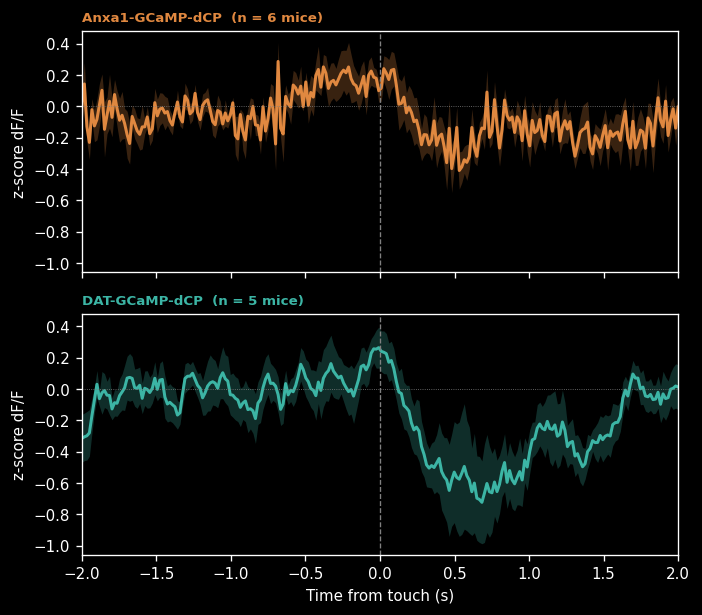

Saved → ../../../nwb_output/water_consumption/figure4D.png


In [6]:
def _pool_cohort(sessions, cohorts):
    """Collect sessions matching any of the given cohort labels."""
    out = defaultdict(list)
    for s in sessions:
        if s["cohort"] not in cohorts or s["peri"] is None:
            continue
        out[s["cohort"]].append(s)
    return out


def plot_panel_manuscript(panel_label, cohorts, fig_title):
    """Plot each cohort in its own row with shared x/y axes, matching manuscript Figure 4 style.

    Sessions are first averaged within each mouse, then the grand mean ± SEM is computed across
    mice. Each cohort occupies its own subplot row; rows share both axes.
    """
    cohort_sessions_dict = _pool_cohort(sessions, cohorts)
    cohorts_present = [c for c in cohorts if c in cohort_sessions_dict]
    if not cohorts_present:
        print(f"Panel {panel_label}: no sessions for {cohorts}")
        return

    n = len(cohorts_present)
    fig, axes = plt.subplots(
        n, 1, figsize=(6, 2.6 * n),
        sharex=True, sharey=True,
        squeeze=False,
    )

    for row, cohort in enumerate(cohorts_present):
        sess_list = cohort_sessions_dict[cohort]
        color = COHORT_COLORS.get(cohort, COHORT_COLORS["other"])
        t_axis = sess_list[0]["peri"]["t_axis"]

        # Average within each mouse (across sessions), then across mice
        mouse_groups = defaultdict(list)
        for s in sess_list:
            mouse_groups[s["subject_id"]].append(s["peri"]["mean"])
        mouse_means = np.array([np.mean(traces, axis=0) for traces in mouse_groups.values()])
        n_mice = len(mouse_means)
        mean = mouse_means.mean(axis=0)
        sem = mouse_means.std(axis=0) / np.sqrt(n_mice) if n_mice > 1 else np.zeros_like(mean)

        ax = axes[row, 0]
        ax.plot(t_axis, mean, color=color, linewidth=1.8)
        ax.fill_between(t_axis, mean - sem, mean + sem, color=color, alpha=0.25, linewidth=0)
        ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
        ax.axhline(0, color="gray", linestyle=":", linewidth=0.5)
        ax.set_xlim(-PRE_S, POST_S)
        ax.set_title(f"{cohort}  (n = {n_mice} mice)", fontsize=8, color=color, fontweight="bold", loc="left")
        ax.set_ylabel("z-score dF/F")
        if row == n - 1:
            ax.set_xlabel("Time from touch (s)")

    plt.tight_layout()
    out = NWB_DIR / f"figure4{panel_label}.png"
    plt.savefig(out, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out}")


plot_panel_manuscript("D", ["Anxa1-GCaMP-dCP", "DAT-GCaMP-dCP"],
                      "z-scored FP aligned to water drop contact — GCaMP cohorts (dCP)")

## Panel E — dLight-dCP vs dLight-cCP

Same layout as Panel D for the dLight cohorts. Water contact elicits a robust dLight transient in
cCP but not dCP, consistent with preferential innervation of cCP by reward-responsive DANs.

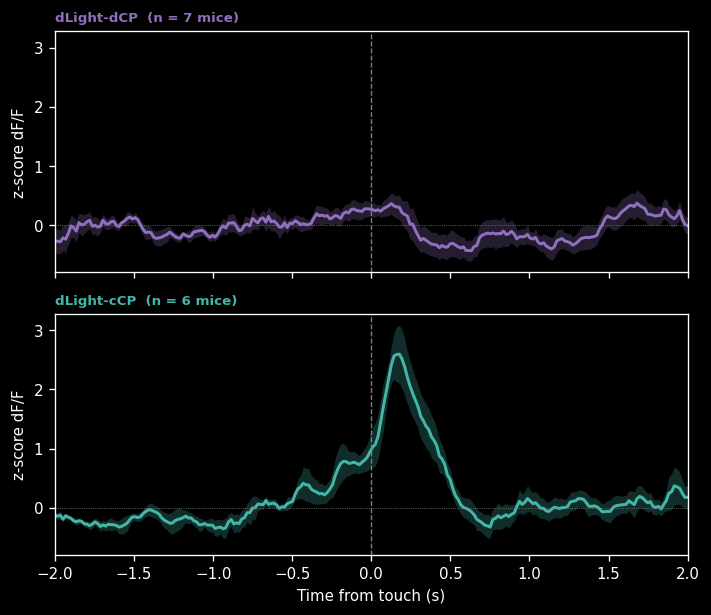

Saved → ../../../nwb_output/water_consumption/figure4E.png


In [7]:
plot_panel_manuscript("E", ["dLight-dCP", "dLight-cCP"],
                      "z-scored FP aligned to water drop contact — dLight cohorts (dCP vs cCP)")

## Panels F – G — AUC changes relative to baseline

Per-session AUC changes in window 2 (ΔW2–W1) and window 3 (ΔW3–W1) relative to the pre-contact
baseline window W1. The manuscript tests these ΔAUC values across cohorts with a Kruskal–Wallis
test (*p < 0.05, Dunn's post hoc). Here we plot the distributions per cohort; statistical tests
are omitted (too few sessions in the currently-converted subset).

In [8]:
# Build a long-form dataframe of delta-AUC per session
delta_rows = []
for s in sessions:
    if s["peri"] is None:
        continue
    w1 = s["aucs"]["W1 (baseline)"]
    w2 = s["aucs"]["W2 (peri-contact)"]
    w3 = s["aucs"]["W3 (post-contact)"]
    delta_rows.append(dict(subject=s["subject_id"], cohort=s["cohort"], contrast="ΔW2–W1", value=w2 - w1))
    delta_rows.append(dict(subject=s["subject_id"], cohort=s["cohort"], contrast="ΔW3–W1", value=w3 - w1))
delta_df = pd.DataFrame(delta_rows)
delta_df

,subject,cohort,contrast,value
0,661507,DAT-GCaMP-dCP,ΔW2–W1,0.010305
1,661507,DAT-GCaMP-dCP,ΔW3–W1,0.014320
2,661507,DAT-GCaMP-dCP,ΔW2–W1,-0.815441
3,661507,DAT-GCaMP-dCP,ΔW3–W1,-0.524223
4,687662,DAT-GCaMP-dCP,ΔW2–W1,-0.140933
...,...,...,...,...
113,842430,Anxa1-GCaMP-dCP,ΔW3–W1,-0.208492
114,842430,Anxa1-GCaMP-dCP,ΔW2–W1,-0.126238
115,842430,Anxa1-GCaMP-dCP,ΔW3–W1,-0.511612
116,842430,Anxa1-GCaMP-dCP,ΔW2–W1,-0.289085


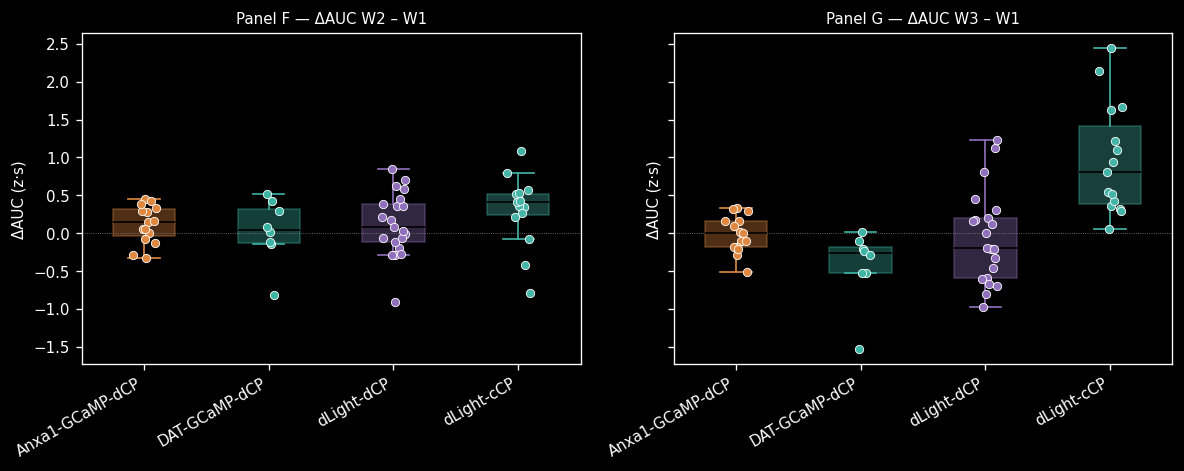

Saved → ../../../nwb_output/water_consumption/figure4FG.pdf


In [9]:
cohorts_ordered = ["Anxa1-GCaMP-dCP", "DAT-GCaMP-dCP", "dLight-dCP", "dLight-cCP"]
cohorts_present = [c for c in cohorts_ordered if c in delta_df["cohort"].unique()]
contrasts = ["ΔW2–W1", "ΔW3–W1"]
panel_titles = {"ΔW2–W1": "Panel F — ΔAUC W2 – W1", "ΔW3–W1": "Panel G — ΔAUC W3 – W1"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, contrast in zip(axes, contrasts):
    for i, cohort in enumerate(cohorts_present):
        vals = delta_df.loc[(delta_df["cohort"] == cohort) & (delta_df["contrast"] == contrast), "value"].to_numpy()
        color = COHORT_COLORS.get(cohort, COHORT_COLORS["other"])
        # box + individual points
        if len(vals) > 0:
            ax.boxplot(
                vals, positions=[i], widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=color, alpha=0.35, edgecolor=color),
                medianprops=dict(color="black"), whiskerprops=dict(color=color),
                capprops=dict(color=color), flierprops=dict(marker=""),
            )
        jitter = (np.random.RandomState(0).rand(len(vals)) - 0.5) * 0.2
        ax.scatter(np.full(len(vals), i) + jitter, vals, color=color, s=25, zorder=3, edgecolor="white", linewidth=0.5)
    ax.axhline(0, color="gray", linestyle=":", linewidth=0.5)
    ax.set_xticks(range(len(cohorts_present)))
    ax.set_xticklabels(cohorts_present, rotation=30, ha="right")
    ax.set_ylabel("ΔAUC (z·s)")
    ax.set_title(panel_titles[contrast], fontsize=9)

plt.tight_layout()
out = NWB_DIR / "figure4FG.pdf"
plt.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

## Per-session QC traces

For transparency, plot each session individually so that cohort-level averages can be audited
against the single-session data (number of contact events, SNR, baseline drift).


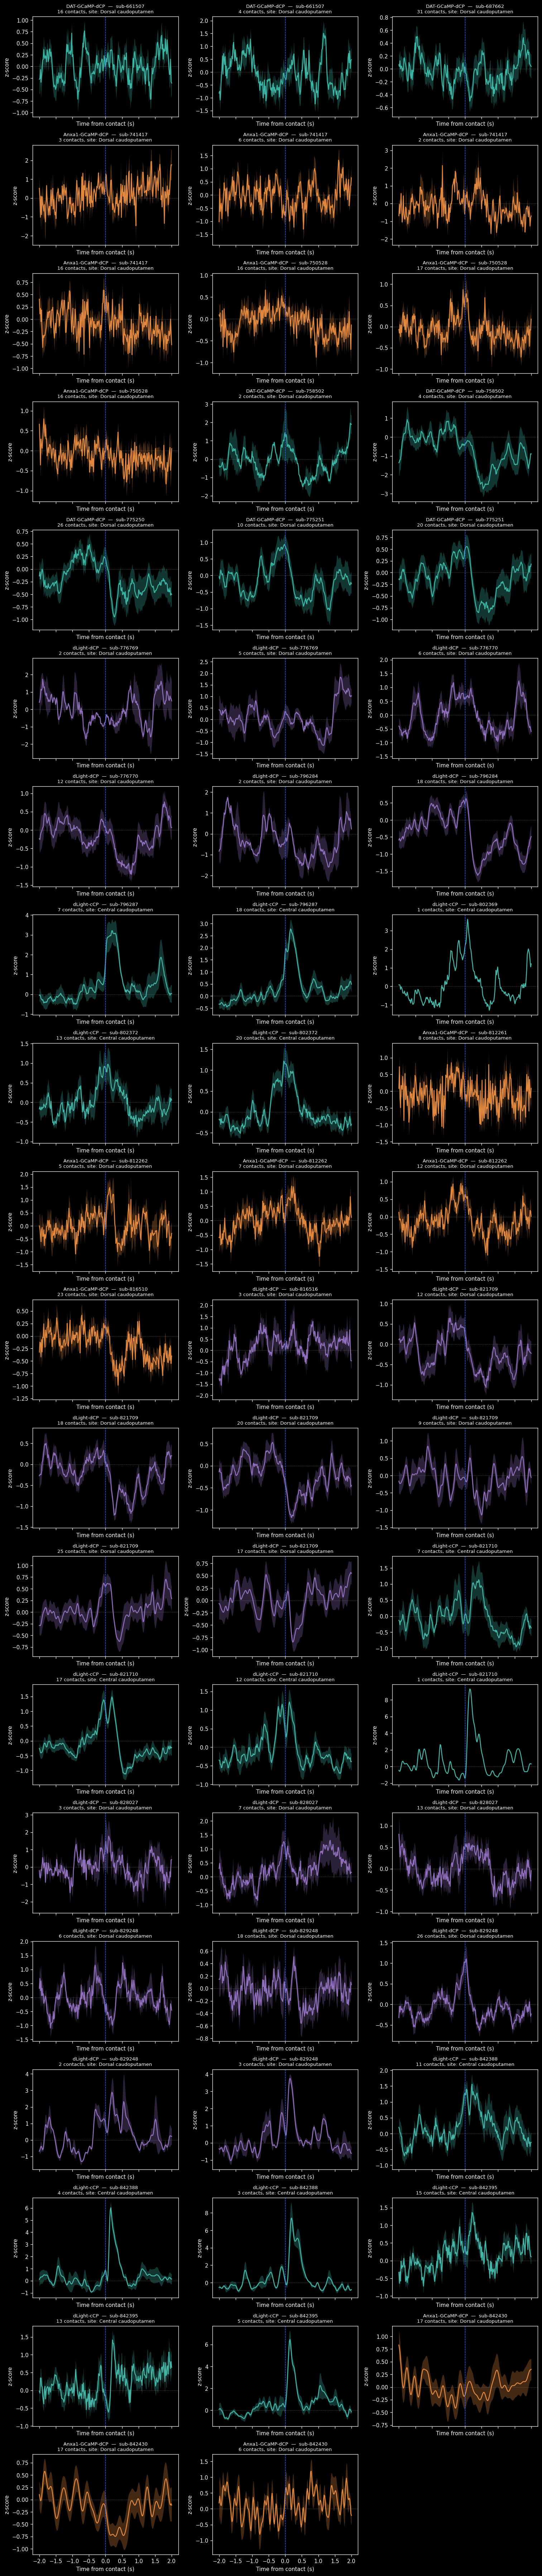

In [10]:
valid = [s for s in sessions if s["peri"] is not None]
if not valid:
    print("No sessions have contact events — nothing to plot.")
else:
    n = len(valid)
    ncols = min(n, 3)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.0 * nrows), sharex=True)
    axes = np.atleast_2d(axes).ravel()
    for ax, s in zip(axes, valid):
        color = COHORT_COLORS.get(s["cohort"], COHORT_COLORS["other"])
        t_axis = s["peri"]["t_axis"]
        mean = s["peri"]["mean"]
        sem = s["peri"]["sem"]
        ax.plot(t_axis, mean, color=color, linewidth=1.5)
        ax.fill_between(t_axis, mean - sem, mean + sem, color=color, alpha=0.3, linewidth=0)
        ax.axvline(0, color="royalblue", linestyle="--", linewidth=0.8)
        ax.axhline(0, color="gray", linestyle=":", linewidth=0.5)
        ax.set_title(f"{s['cohort']}  —  sub-{s['subject_id']}\n{s['peri']['n_epochs']} contacts, site: {s['location']}", fontsize=8)
        ax.set_xlabel("Time from contact (s)")
        ax.set_ylabel("z-score")
    for ax in axes[len(valid):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()